In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from tqdm.notebook import trange

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.join(os.path.abspath(_module_path), "src"))

from utils.data_utils import get_datapath

In [2]:
DATASET_NR = 0
NUM_SU = 21

datapath = get_datapath(_repo_name)
datapath = os.path.join(datapath, str(DATASET_NR))

min_max = pd.read_csv(os.path.join(datapath, "spectrogram_min_max.csv"))
min_val = min_max["min_val"].values[0]
max_val = min_max["max_val"].values[0]

labels = pd.read_csv(os.path.join(datapath, "labels.csv"))
labels

,jammer_type,jammer_power,jammer_location,num_legitimate_transmitters,snr_by_su_0,snr_by_su_1,snr_by_su_2,snr_by_su_3,snr_by_su_4,snr_by_su_5,...,sjr_by_su_11,sjr_by_su_12,sjr_by_su_13,sjr_by_su_14,sjr_by_su_15,sjr_by_su_16,sjr_by_su_17,sjr_by_su_18,sjr_by_su_19,sjr_by_su_20
0,no jammer,NaN,NaN,7,11.205190,36.394835,28.633557,32.830631,27.876210,28.368506,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
1,no jammer,NaN,NaN,10,37.181006,27.196118,26.667923,26.924856,31.292516,23.784618,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2,no jammer,NaN,NaN,4,16.792065,1.658751,15.343251,18.833420,28.515733,24.952806,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
3,no jammer,NaN,NaN,3,8.612550,20.931185,15.208468,24.046144,23.241120,4.563992,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
4,no jammer,NaN,NaN,6,23.530386,27.329550,20.605191,34.162754,28.238471,28.724330,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,random_hop,30.0,[35.51274735 19.92471911 1.5 ],3,47.406463,23.909494,11.627974,20.348687,16.331165,18.177022,...,-11.077470,1.883115,-6.844181,4.848347,-10.239276,-14.790576,-7.134045,-12.401833,-4.683988,-0.979003
19996,random_hop,20.0,[12.43643717 33.69950206 1.5 ],7,27.724150,30.047037,32.080249,28.966197,28.519574,39.414356,...,9.144673,4.178095,1.110013,-3.856498,7.007394,6.129318,-9.036473,-2.747978,-8.603953,-7.914939
19997,random_hop,25.0,[27.04544549 24.729692 1.5 ],6,33.530590,21.523479,25.318172,22.280053,10.522822,29.939076,...,17.265862,0.561977,6.202771,10.222053,0.146705,-9.631842,-10.114241,10.677068,-4.634555,-2.471883
19998,random_hop,10.0,[0.85910261 9.04560102 1.5 ],5,28.869627,27.791972,18.966235,9.829562,14.671112,19.737416,...,53.275415,-2.567677,6.091866,17.360764,10.718381,11.890497,17.143208,10.800973,25.274579,10.850180


In [3]:
def get_filename(sample_idx, su_idx):
    return os.path.join(datapath, "images", f"spectrogram-{str(sample_idx).zfill(5)}-{str(su_idx).zfill(2)}.png")

In [ ]:
min_values = np.ones(len(labels)*NUM_SU) * np.nan
max_values = np.ones(len(labels)*NUM_SU) * np.nan

for sample_idx in trange(0, len(labels), 10):
    for su_idx in range(NUM_SU):
        img = Image.open(get_filename(sample_idx, su_idx))
        img = np.array(img)/255.0 * (max_val - min_val) + min_val
        min_values[sample_idx * NUM_SU + su_idx] = np.min(img)
        max_values[sample_idx * NUM_SU + su_idx] = np.max(img)

# drop NaN values
min_values = min_values[~np.isnan(min_values)]
max_values = max_values[~np.isnan(max_values)]

print(f"Number of spectrograms considered: {len(min_values)}")

  0%|          | 0/2000 [00:00<?, ?it/s]

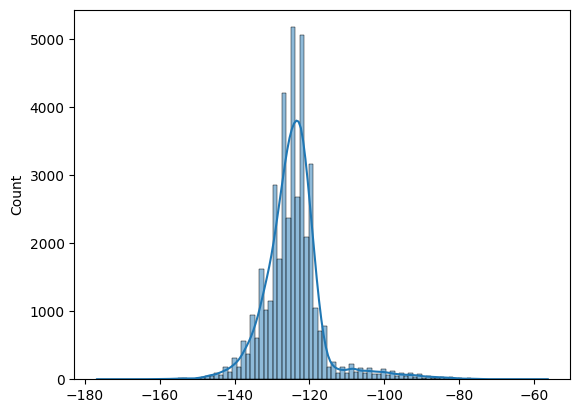

1st percentile of min values: -142.932545972549


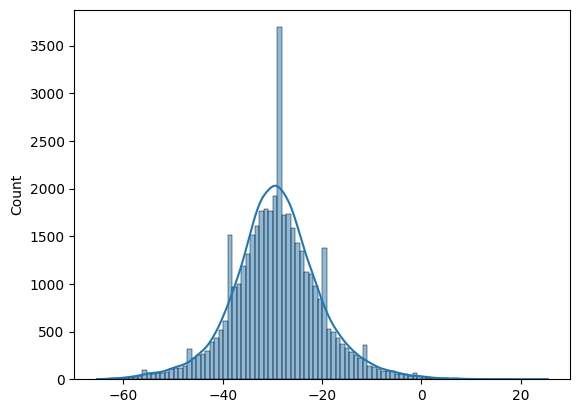

99th percentile of max values: -5.052288164705885
Original resolution at 8 bit (min: -183.38843, max: 27.147293): 0.82240516796875
Resolution when limiting to 1st and 99th percentile: 0.5385947570618872


In [10]:
sns.histplot(min_values, bins=100, kde=True)
plt.show()

print(f"1st percentile of min values: {np.percentile(min_values, 1)}")

sns.histplot(max_values, bins=100, kde=True)
plt.show()

print(f"99th percentile of max values: {np.percentile(max_values, 99)}")

print(f"Original resolution at 8 bit (min: {min_val}, max: {max_val}): {(max_val - min_val)/2**8}")
print(f"Resolution when limiting to 1st and 99th percentile: {(np.percentile(max_values, 99) - np.percentile(min_values, 1))/2**8}")